# Airline Passenger Satisfaction - Exploratory Data Analysis
# Author: Pedro M.
# Enhanced Version with Advanced Analytics

#  🛫 Airline Passenger Satisfaction - Exploratory Data Analysis
## Table of Contents
# 1. Introduction
# 2. Data Loading and Overview
# 3. Data Quality Assessment
# 4. Univariate Analysis
# 5. Bivariate Analysis
# 6. Multivariate Analysis
# 7. Customer Segmentation Analysis
# 8. Key Insights and Recommendations
# 9. Conclusions


## 1. Introduction


# This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the Airline Passenger Satisfaction dataset.
# The goal is to understand what factors contribute to passenger satisfaction and identify patterns that could help airlines improve their services.


## 2. Data Loading and Overview

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
# Note: Update the path according to your file location
df = pd.read_csv('./data/train.csv')  # Assuming the dataset is named 'train.csv'

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\n" + "="*50 + "\n")

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*50 + "\n")

# Display column names and data types
print("Dataset Information:")
print(df.info())
print("\n" + "="*50 + "\n")

# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50 + "\n")

# Check column names
print("Column Names:")
print(df.columns.tolist())

Dataset Shape: (103904, 25)


First 5 rows of the dataset:
   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                          

## 3. Data Quality Assessment

Missing Values Analysis:
                          Missing_Count  Percentage
Arrival Delay in Minutes            310    0.298352


<Figure size 1200x600 with 0 Axes>

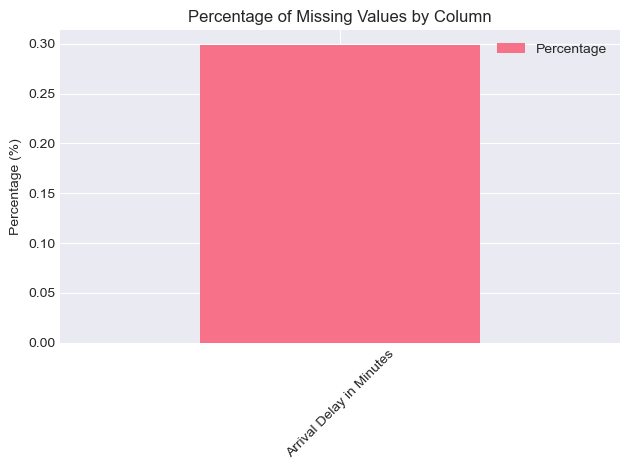


Number of duplicate rows: 0

Data Types Summary:
int64      19
object      5
float64     1
Name: count, dtype: int64


In [4]:
# Check for missing values
print("Missing Values Analysis:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

# Visualize missing values
if missing_values.sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_df[missing_df['Missing_Count'] > 0].plot(kind='bar', y='Percentage')
    plt.title('Percentage of Missing Values by Column')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Data type analysis
print("\nData Types Summary:")
print(df.dtypes.value_counts())

## 4. Univariate Analysis

### 4.1 Target Variable Distribution

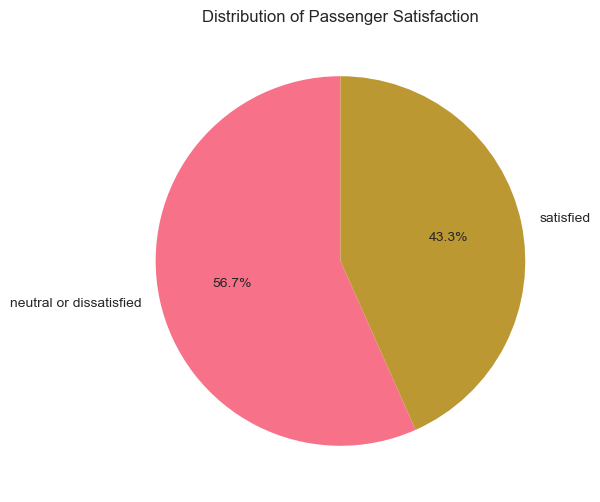

In [5]:
plt.figure(figsize=(8, 6))
satisfaction_counts = df['satisfaction'].value_counts()
plt.pie(satisfaction_counts.values, labels=satisfaction_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Passenger Satisfaction')
plt.show()

### 4.2 Demographic Analysis

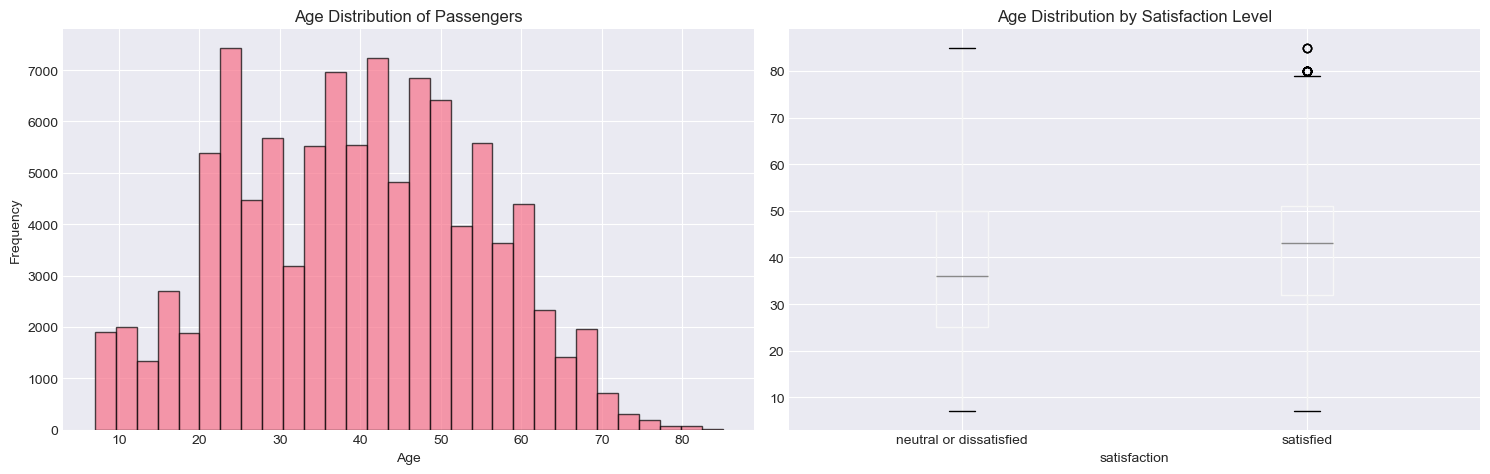

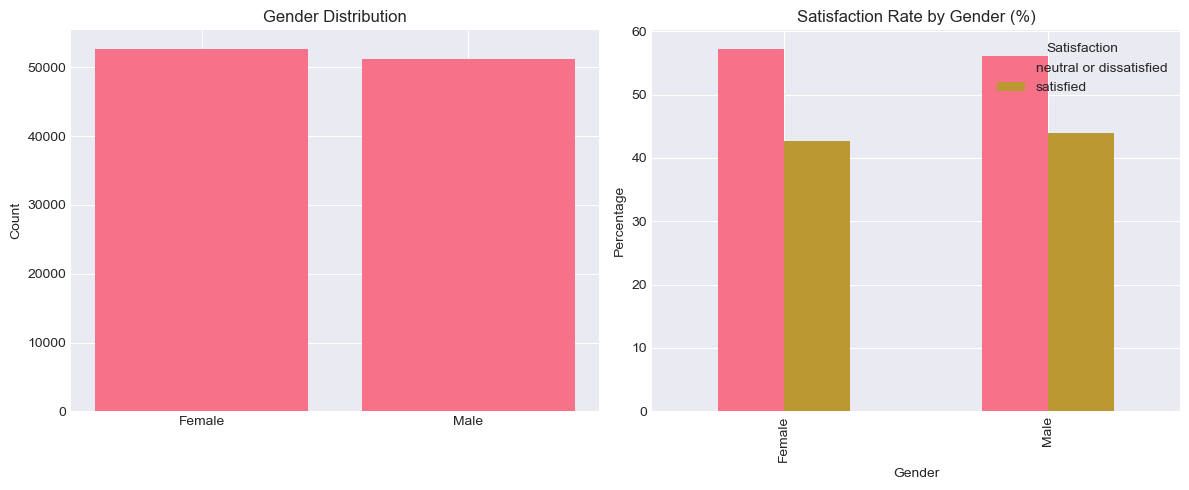

In [6]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age histogram
axes[0].hist(df['Age'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution of Passengers')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Age boxplot by satisfaction
df.boxplot(column='Age', by='satisfaction', ax=axes[1])
axes[1].set_title('Age Distribution by Satisfaction Level')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender count
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values)
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')

# Gender by satisfaction
gender_satisfaction = pd.crosstab(df['Gender'], df['satisfaction'], normalize='index') * 100
gender_satisfaction.plot(kind='bar', ax=axes[1])
axes[1].set_title('Satisfaction Rate by Gender (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
plt.tight_layout()
plt.show()

### 4.3 Travel Information Analysis

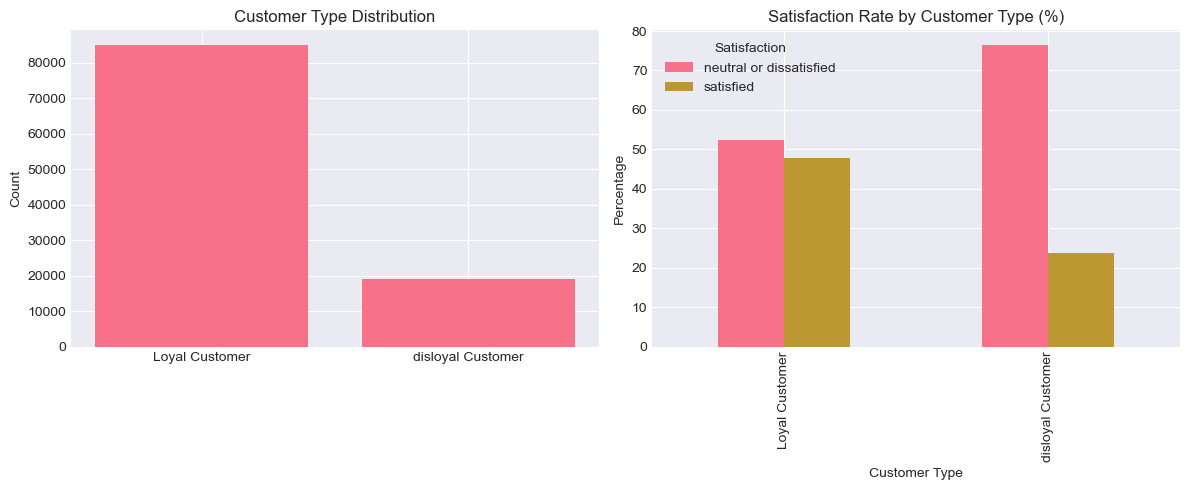

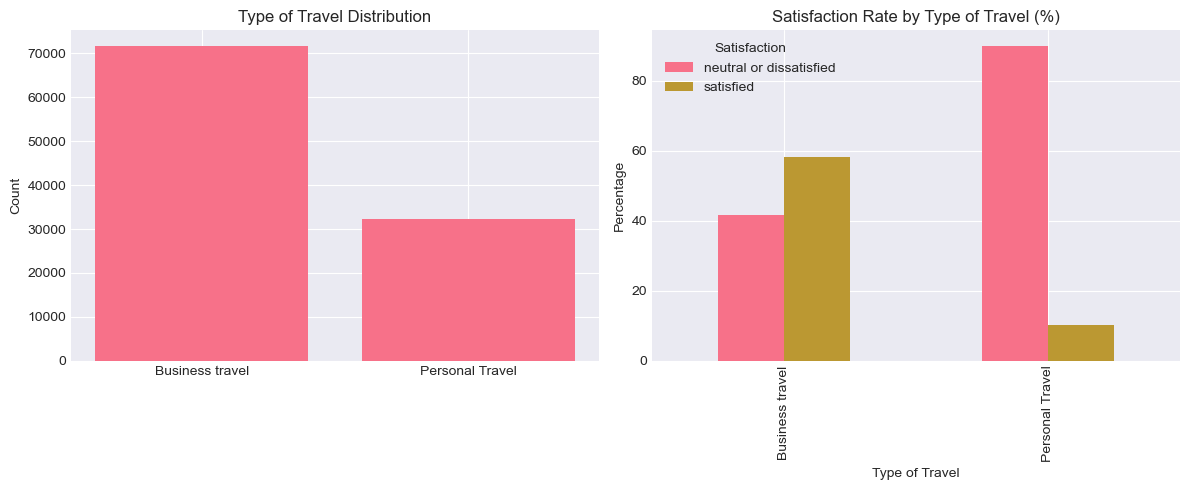

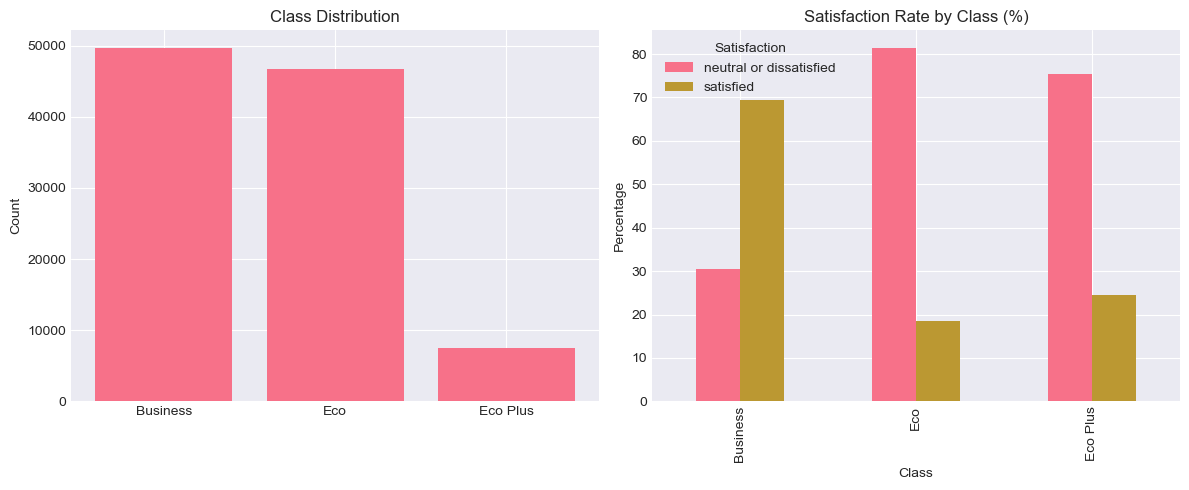

In [7]:
# Customer Type
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

customer_counts = df['Customer Type'].value_counts()
axes[0].bar(customer_counts.index, customer_counts.values)
axes[0].set_title('Customer Type Distribution')
axes[0].set_ylabel('Count')

# Customer type by satisfaction
customer_satisfaction = pd.crosstab(df['Customer Type'], df['satisfaction'], normalize='index') * 100
customer_satisfaction.plot(kind='bar', ax=axes[1])
axes[1].set_title('Satisfaction Rate by Customer Type (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
plt.tight_layout()
plt.show()

# Type of Travel
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

travel_counts = df['Type of Travel'].value_counts()
axes[0].bar(travel_counts.index, travel_counts.values)
axes[0].set_title('Type of Travel Distribution')
axes[0].set_ylabel('Count')

# Type of travel by satisfaction
travel_satisfaction = pd.crosstab(df['Type of Travel'], df['satisfaction'], normalize='index') * 100
travel_satisfaction.plot(kind='bar', ax=axes[1])
axes[1].set_title('Satisfaction Rate by Type of Travel (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
plt.tight_layout()
plt.show()

# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts = df['Class'].value_counts()
axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Class by satisfaction
class_satisfaction = pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100
class_satisfaction.plot(kind='bar', ax=axes[1])
axes[1].set_title('Satisfaction Rate by Class (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Satisfaction')
plt.tight_layout()
plt.show()

### 4.4 Flight Distance Analysis

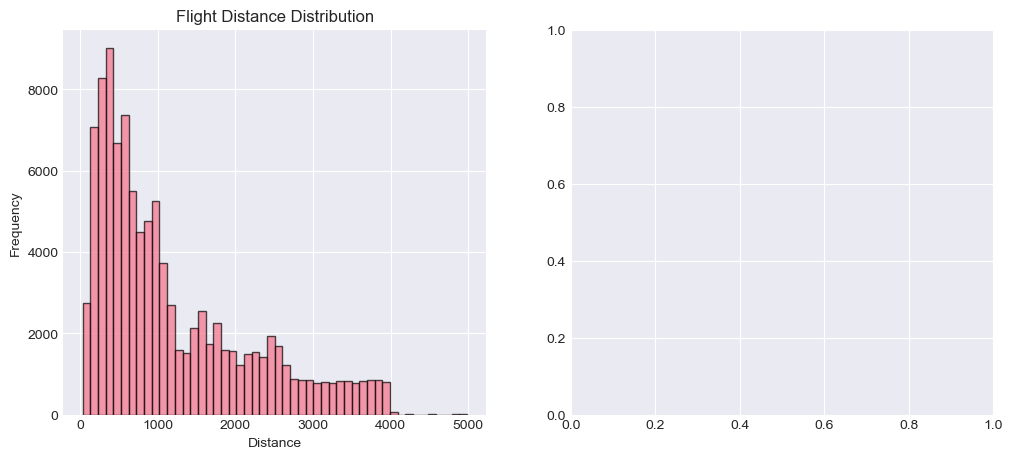

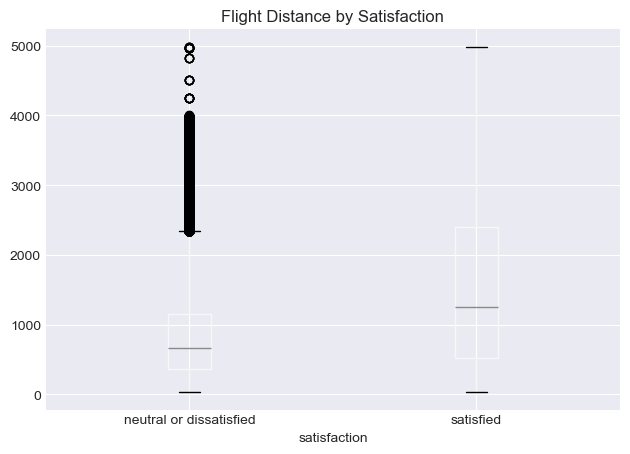

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Flight Distance'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Flight Distance Distribution')
plt.xlabel('Distance')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.boxplot(column='Flight Distance', by='satisfaction')
plt.title('Flight Distance by Satisfaction')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 4.5 Delay Analysis

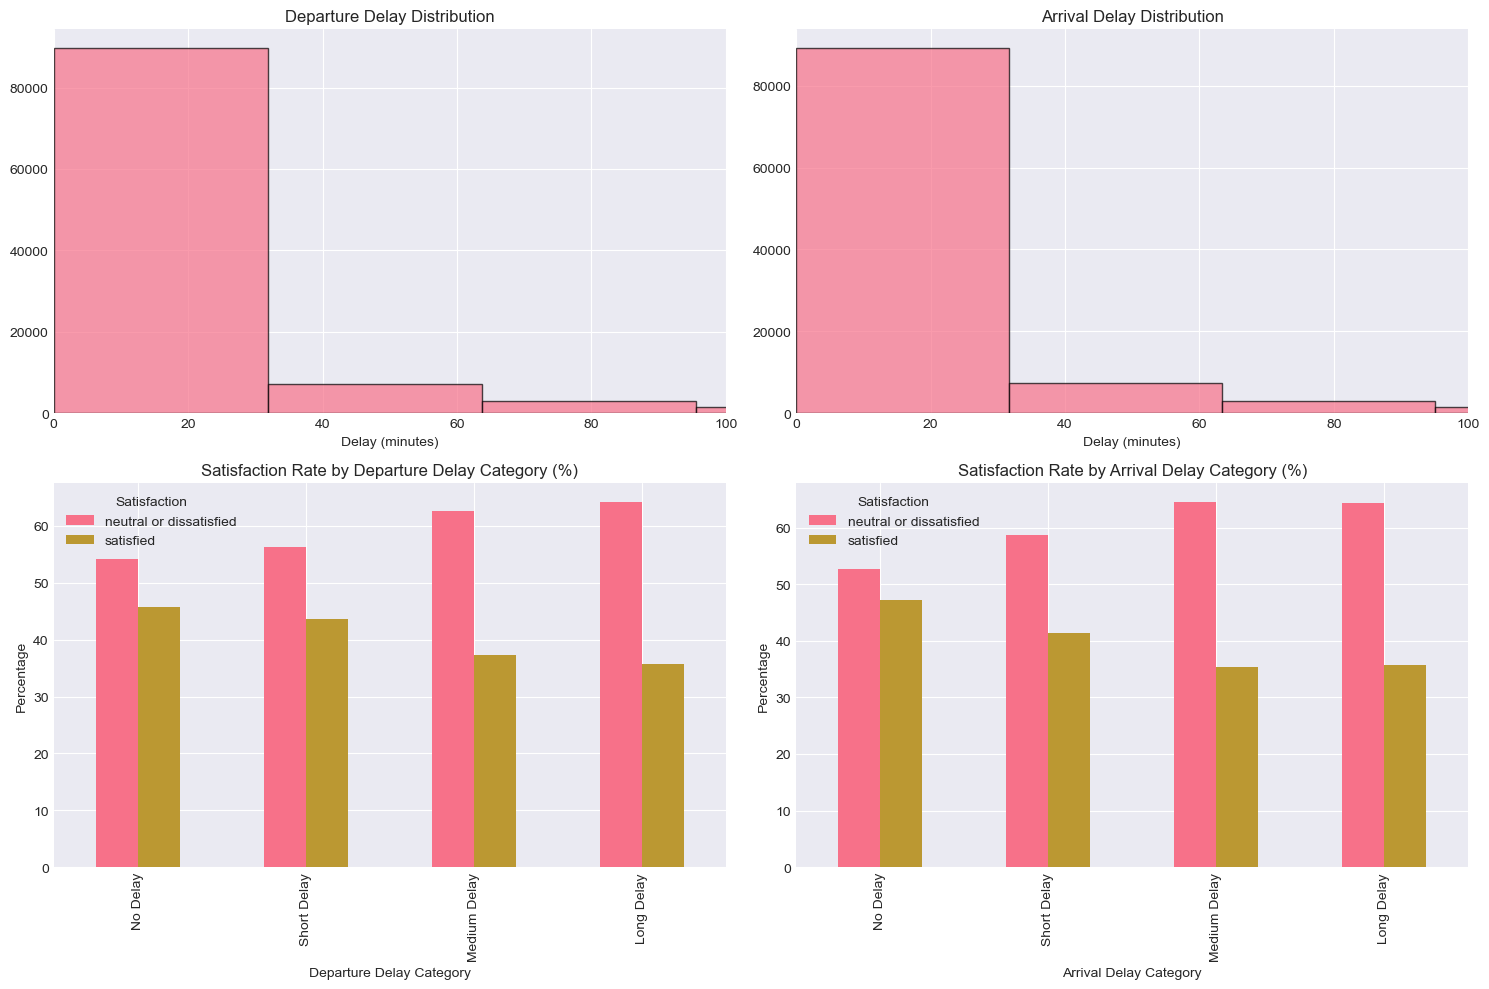

In [10]:
# Create delay categories
df['Departure Delay Category'] = pd.cut(df['Departure Delay in Minutes'], 
                                        bins=[-1, 0, 15, 60, 1000], 
                                        labels=['No Delay', 'Short Delay', 'Medium Delay', 'Long Delay'])

df['Arrival Delay Category'] = pd.cut(df['Arrival Delay in Minutes'], 
                                      bins=[-1, 0, 15, 60, 1000], 
                                      labels=['No Delay', 'Short Delay', 'Medium Delay', 'Long Delay'])

# Delay distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Departure delay distribution
axes[0, 0].hist(df['Departure Delay in Minutes'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Departure Delay Distribution')
axes[0, 0].set_xlabel('Delay (minutes)')
axes[0, 0].set_xlim(0, 100)  # Limit x-axis for better visualization

# Arrival delay distribution
axes[0, 1].hist(df['Arrival Delay in Minutes'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Arrival Delay Distribution')
axes[0, 1].set_xlabel('Delay (minutes)')
axes[0, 1].set_xlim(0, 100)

# Departure delay by satisfaction
dep_delay_satisfaction = pd.crosstab(df['Departure Delay Category'], df['satisfaction'], normalize='index') * 100
dep_delay_satisfaction.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Satisfaction Rate by Departure Delay Category (%)')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].legend(title='Satisfaction')

# Arrival delay by satisfaction
arr_delay_satisfaction = pd.crosstab(df['Arrival Delay Category'], df['satisfaction'], normalize='index') * 100
arr_delay_satisfaction.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Satisfaction Rate by Arrival Delay Category (%)')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Satisfaction')

plt.tight_layout()
plt.show()


## 5. Bivariate Analysis


### 5.1 Service Ratings Analysis

Service rating columns found:
['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']


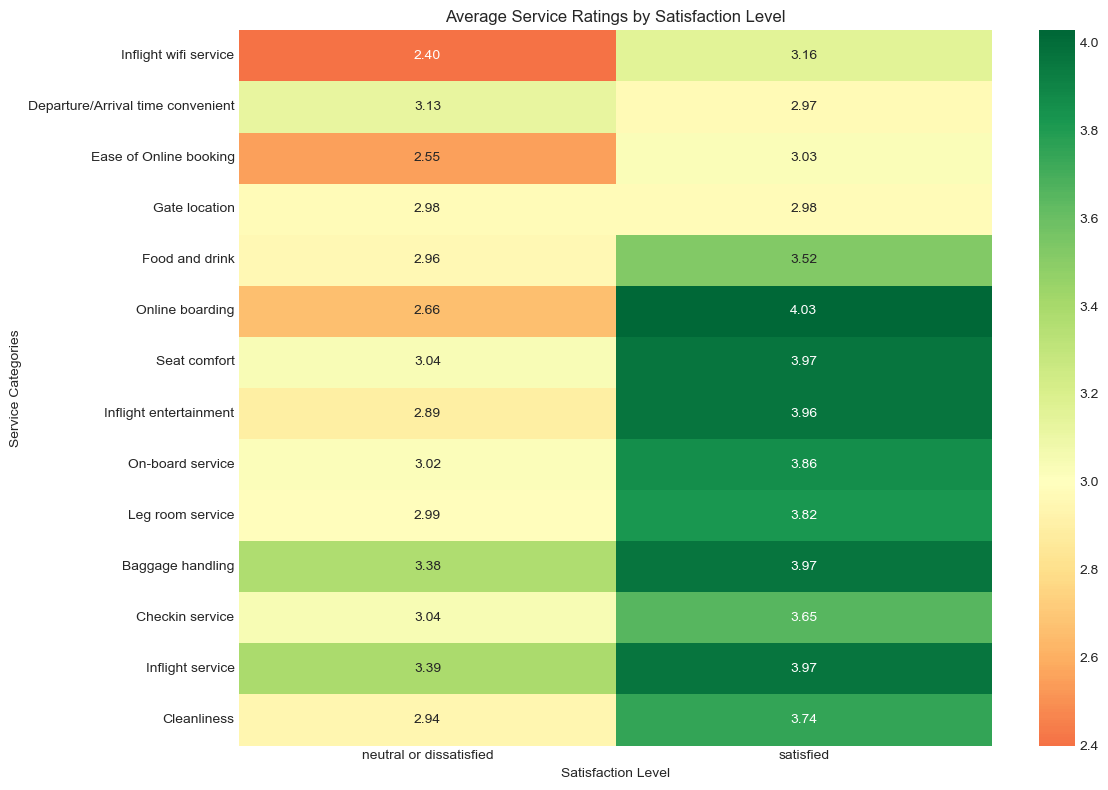

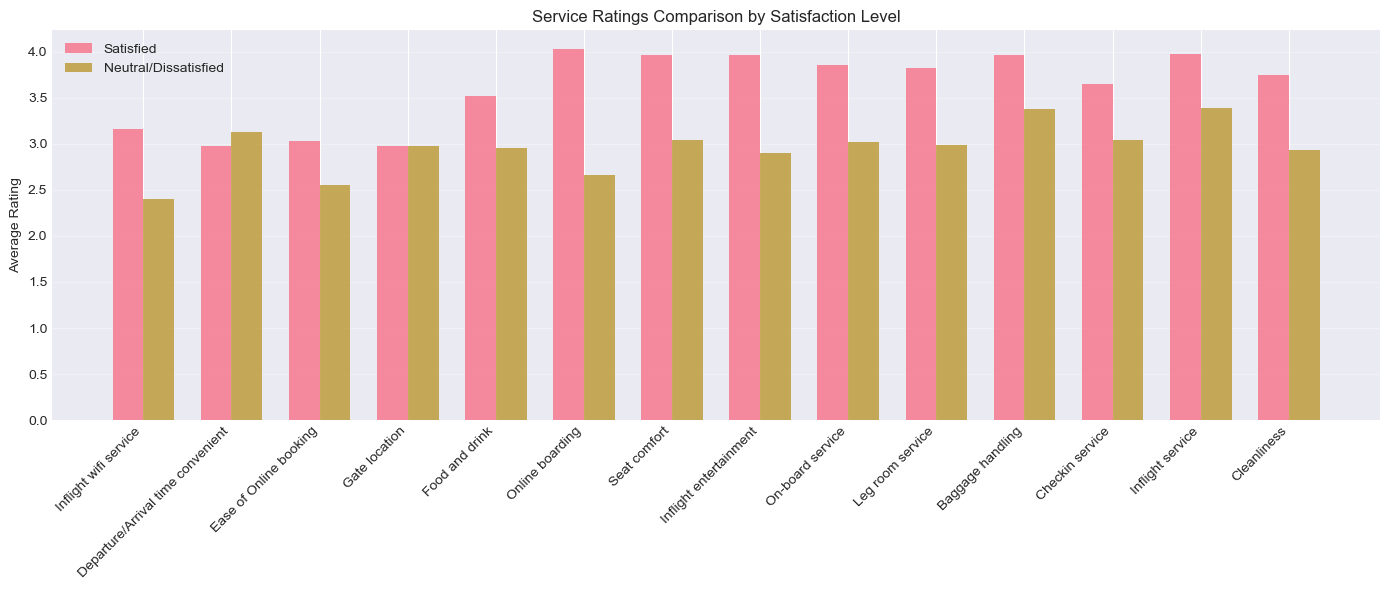

In [11]:
# Identify service rating columns (assuming they have ratings from 0-5)
service_columns = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] 
                   and df[col].nunique() <= 6 
                   and df[col].min() >= 0 
                   and df[col].max() <= 5
                   and col not in ['id', 'Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']]

print("Service rating columns found:")
print(service_columns)

# Calculate average ratings by satisfaction
if service_columns:
    avg_ratings = df.groupby('satisfaction')[service_columns].mean()
    
    # Create heatmap of average ratings
    plt.figure(figsize=(12, 8))
    sns.heatmap(avg_ratings.T, annot=True, fmt='.2f', cmap='RdYlGn', center=3)
    plt.title('Average Service Ratings by Satisfaction Level')
    plt.xlabel('Satisfaction Level')
    plt.ylabel('Service Categories')
    plt.tight_layout()
    plt.show()
    
    # Bar plot comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(service_columns))
    width = 0.35
    
    satisfied_ratings = avg_ratings.loc['satisfied'] if 'satisfied' in avg_ratings.index else None
    dissatisfied_ratings = avg_ratings.loc['neutral or dissatisfied'] if 'neutral or dissatisfied' in avg_ratings.index else None
    
    if satisfied_ratings is not None and dissatisfied_ratings is not None:
        ax.bar(x - width/2, satisfied_ratings, width, label='Satisfied', alpha=0.8)
        ax.bar(x + width/2, dissatisfied_ratings, width, label='Neutral/Dissatisfied', alpha=0.8)
        
        ax.set_ylabel('Average Rating')
        ax.set_title('Service Ratings Comparison by Satisfaction Level')
        ax.set_xticks(x)
        ax.set_xticklabels(service_columns, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

### 5.2 Correlation Analysis

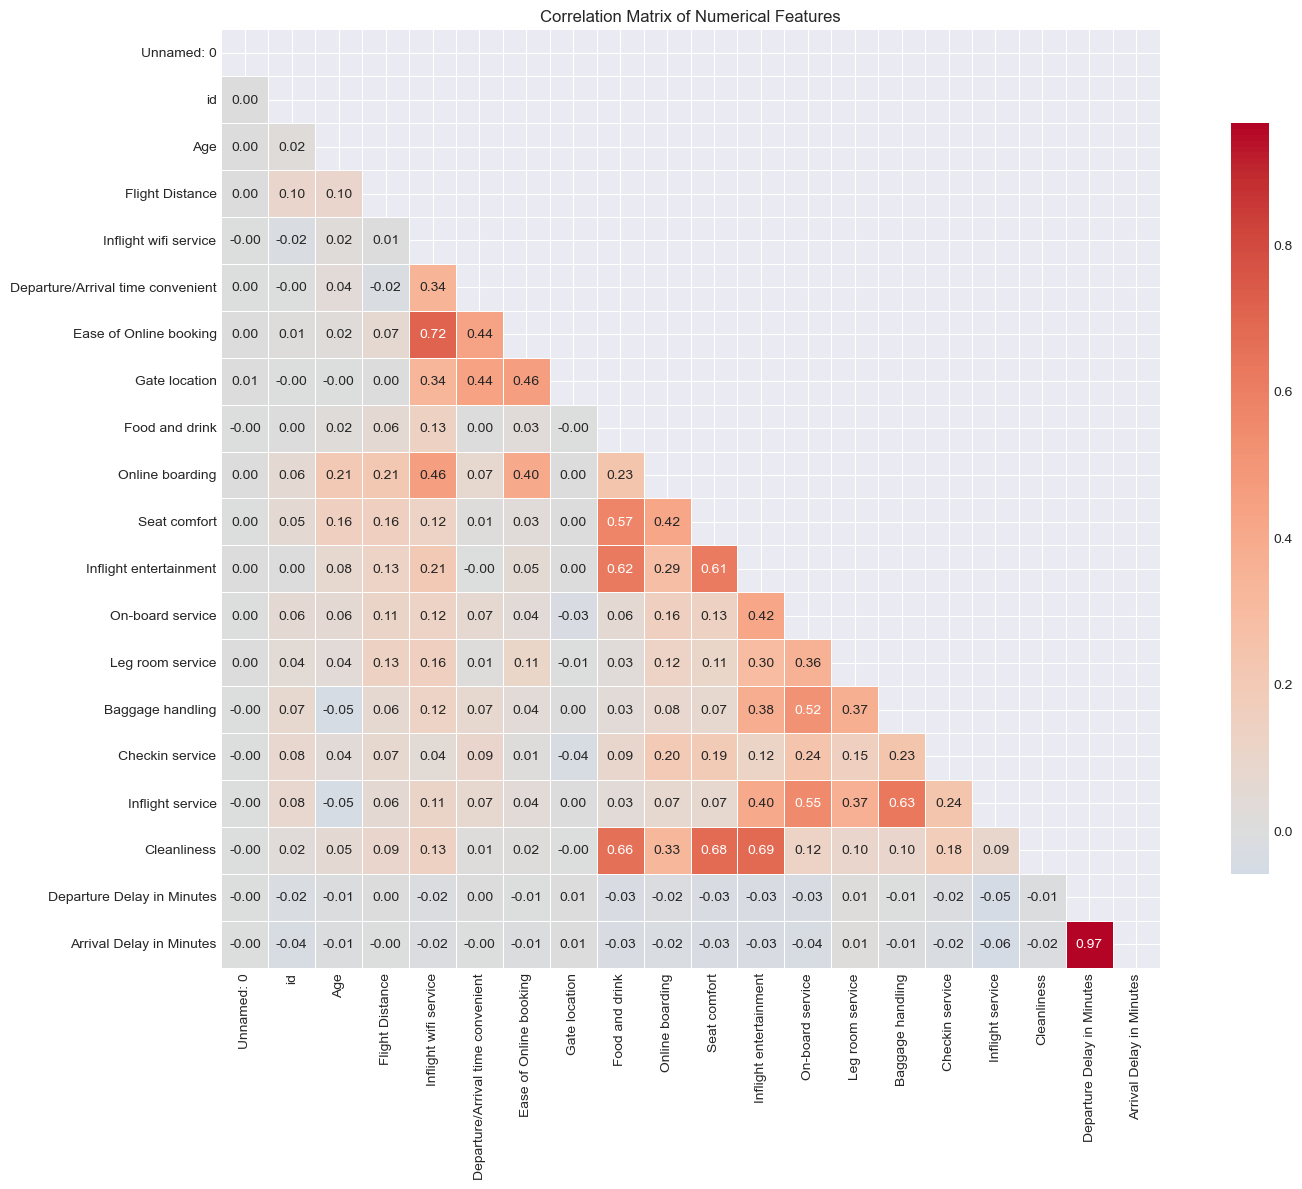

In [12]:
# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Create correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 6. Multivariate Analysis

### 6.1 Feature Importance for Satisfaction

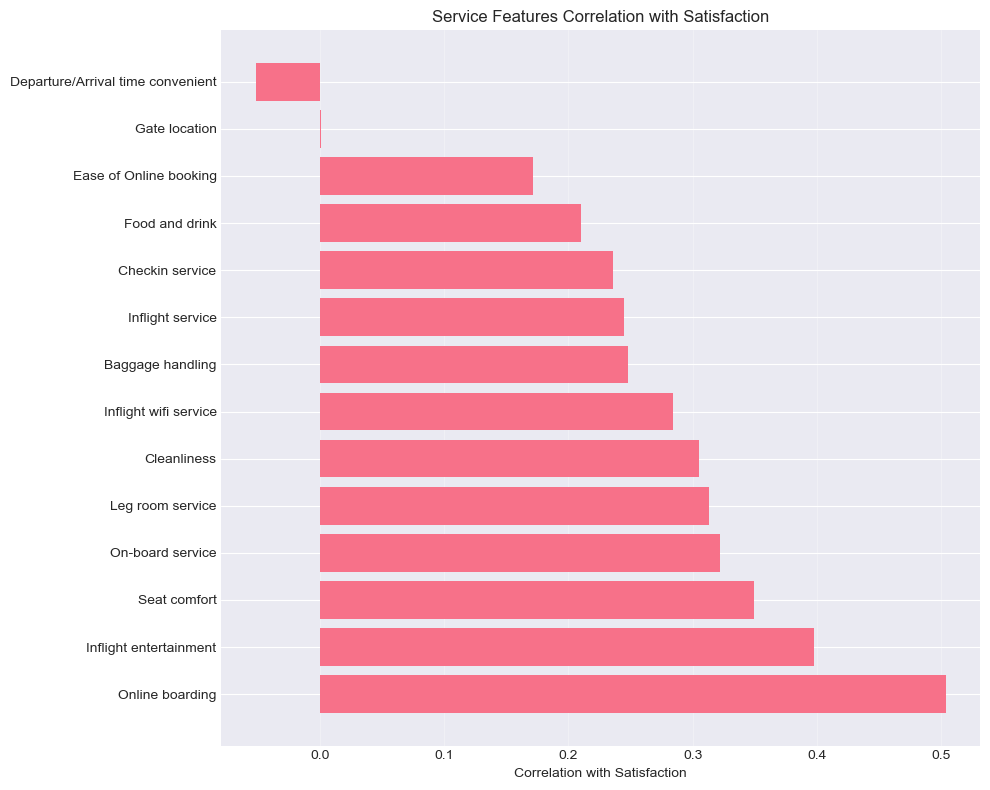

In [13]:
# Create binary satisfaction variable
df['satisfied_binary'] = (df['satisfaction'] == 'satisfied').astype(int)

# Calculate point-biserial correlation for service ratings
if service_columns:
    correlations = []
    for col in service_columns:
        corr, p_value = stats.pointbiserialr(df['satisfied_binary'], df[col])
        correlations.append({'Feature': col, 'Correlation': corr, 'P-value': p_value})
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(corr_df['Feature'], corr_df['Correlation'])
    plt.xlabel('Correlation with Satisfaction')
    plt.title('Service Features Correlation with Satisfaction')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 6.2 Customer Segments Analysis

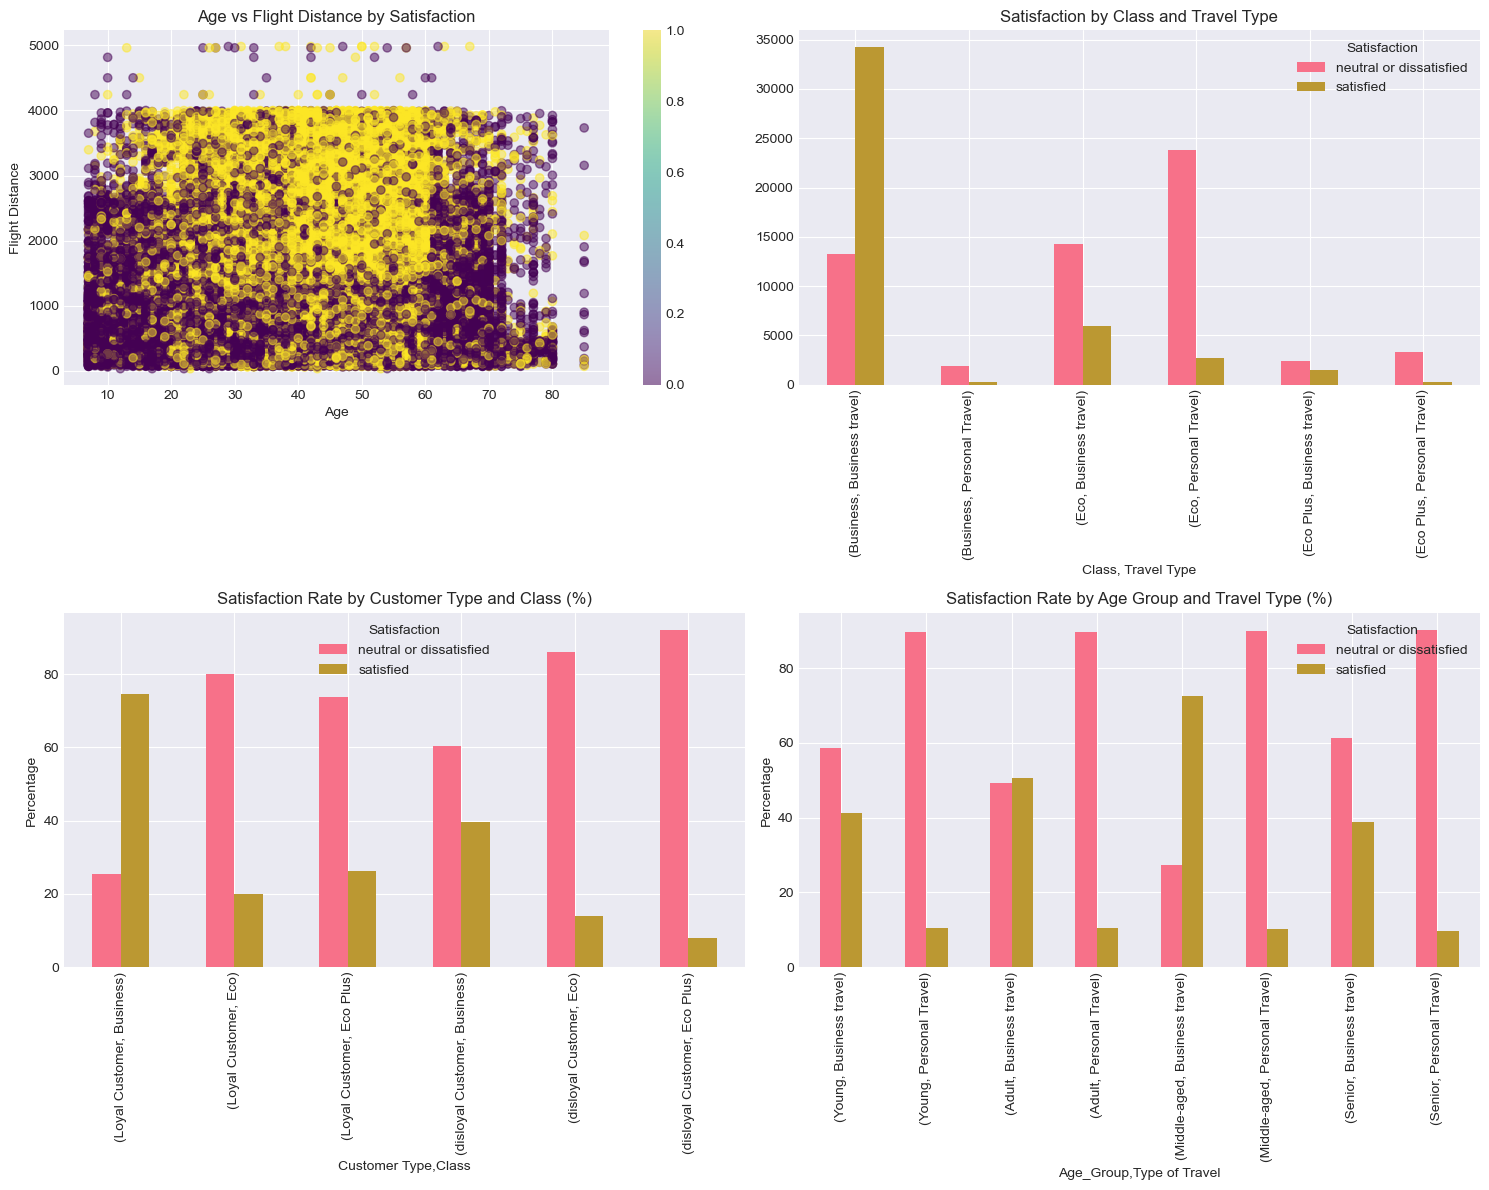

In [14]:
# Create customer segments based on multiple features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Segment 1: Age vs Flight Distance by Satisfaction
scatter1 = axes[0, 0].scatter(df['Age'], df['Flight Distance'], 
                              c=df['satisfied_binary'], cmap='viridis', alpha=0.5)
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Flight Distance')
axes[0, 0].set_title('Age vs Flight Distance by Satisfaction')
plt.colorbar(scatter1, ax=axes[0, 0])

# Segment 2: Class and Type of Travel
segment_data = pd.crosstab([df['Class'], df['Type of Travel']], df['satisfaction'])
segment_data.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Satisfaction by Class and Travel Type')
axes[0, 1].set_xlabel('Class, Travel Type')
axes[0, 1].legend(title='Satisfaction')

# Segment 3: Customer Type and Class
loyalty_class = pd.crosstab([df['Customer Type'], df['Class']], df['satisfaction'], normalize='index') * 100
loyalty_class.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Satisfaction Rate by Customer Type and Class (%)')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].legend(title='Satisfaction')

# Segment 4: Age groups and Travel Type
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 40, 60, 100], labels=['Young', 'Adult', 'Middle-aged', 'Senior'])
age_travel = pd.crosstab([df['Age_Group'], df['Type of Travel']], df['satisfaction'], normalize='index') * 100
age_travel.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Satisfaction Rate by Age Group and Travel Type (%)')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Satisfaction')

plt.tight_layout()
plt.show()

## 7. Customer Segmentation Analysis

### 7.1 Profile of Satisfied vs Dissatisfied Customers

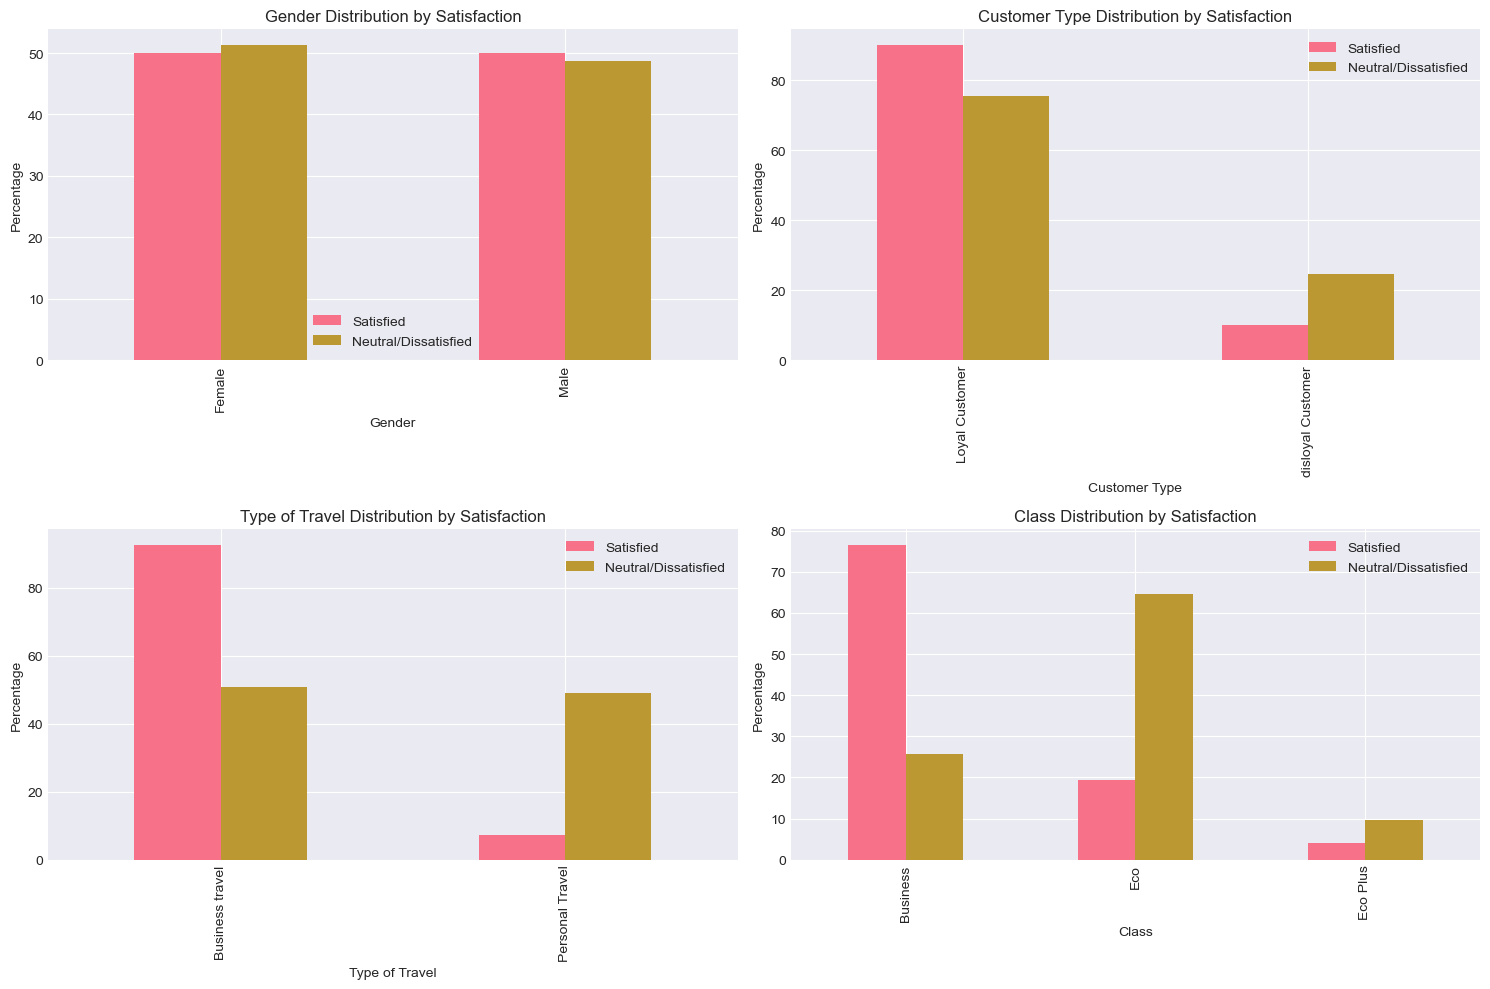

In [17]:
# Create comprehensive customer profiles
satisfied_df = df[df['satisfaction'] == 'satisfied']
dissatisfied_df = df[df['satisfaction'] == 'neutral or dissatisfied']

profile_features = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(profile_features):
    satisfied_profile = satisfied_df[feature].value_counts(normalize=True) * 100
    dissatisfied_profile = dissatisfied_df[feature].value_counts(normalize=True) * 100
    
    comparison_df = pd.DataFrame({
        'Satisfied': satisfied_profile,
        'Neutral/Dissatisfied': dissatisfied_profile
    })
    
    comparison_df.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{feature} Distribution by Satisfaction')
    axes[i].set_ylabel('Percentage')
    axes[i].legend()

plt.tight_layout()
plt.show()


### 7.2 Service Quality Perception Analysis

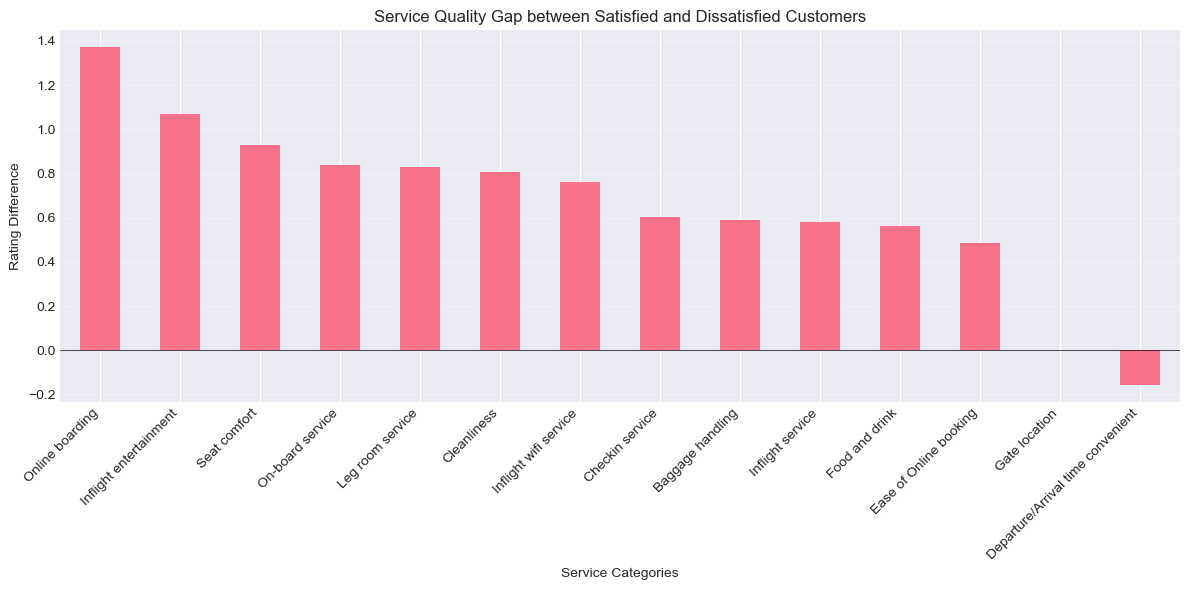

In [18]:
if service_columns:
    # Calculate service quality gaps
    service_gaps = avg_ratings.loc['satisfied'] - avg_ratings.loc['neutral or dissatisfied']
    service_gaps = service_gaps.sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    service_gaps.plot(kind='bar')
    plt.title('Service Quality Gap between Satisfied and Dissatisfied Customers')
    plt.ylabel('Rating Difference')
    plt.xlabel('Service Categories')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Key Insights and Recommendations

### 8.1 Statistical Summary by Satisfaction Level

In [19]:
# Create summary statistics
summary_stats = df.groupby('satisfaction').agg({
    'Age': ['mean', 'std'],
    'Flight Distance': ['mean', 'std'],
    'Departure Delay in Minutes': ['mean', 'median'],
    'Arrival Delay in Minutes': ['mean', 'median']
}).round(2)

print("Statistical Summary by Satisfaction Level:")
print(summary_stats)

Statistical Summary by Satisfaction Level:
                           Age        Flight Distance           \
                          mean    std            mean      std   
satisfaction                                                     
neutral or dissatisfied  37.57  16.46          928.92   790.45   
satisfied                41.75  12.77         1530.14  1128.13   

                        Departure Delay in Minutes         \
                                              mean median   
satisfaction                                                
neutral or dissatisfied                      16.50    0.0   
satisfied                                    12.61    0.0   

                        Arrival Delay in Minutes         
                                            mean median  
satisfaction                                             
neutral or dissatisfied                    17.13    0.0  
satisfied                                  12.63    0.0  


### 8.2 Key Findings Summary

In [20]:
# Calculate key metrics
total_passengers = len(df)
satisfaction_rate = (len(satisfied_df) / total_passengers) * 100

print("\n" + "="*50)
print("KEY FINDINGS SUMMARY")
print("="*50)
print(f"\n1. Overall Satisfaction Rate: {satisfaction_rate:.1f}%")

# Top factors for satisfaction (if service columns exist)
if service_columns and 'corr_df' in locals():
    print("\n2. Top 5 Service Factors Most Correlated with Satisfaction:")
    for i, row in corr_df.head(5).iterrows():
        print(f"   - {row['Feature']}: {row['Correlation']:.3f}")

# Customer segment insights
print("\n3. Customer Segment Insights:")
business_satisfaction = df[df['Type of Travel'] == 'Business travel']['satisfaction'].value_counts(normalize=True)
if 'satisfied' in business_satisfaction.index:
    print(f"   - Business travelers satisfaction rate: {business_satisfaction['satisfied']*100:.1f}%")

business_class_satisfaction = df[df['Class'] == 'Business']['satisfaction'].value_counts(normalize=True)
if 'satisfied' in business_class_satisfaction.index:
    print(f"   - Business class satisfaction rate: {business_class_satisfaction['satisfied']*100:.1f}%")

loyal_satisfaction = df[df['Customer Type'] == 'Loyal Customer']['satisfaction'].value_counts(normalize=True)
if 'satisfied' in loyal_satisfaction.index:
    print(f"   - Loyal customers satisfaction rate: {loyal_satisfaction['satisfied']*100:.1f}%")




KEY FINDINGS SUMMARY

1. Overall Satisfaction Rate: 43.3%

2. Top 5 Service Factors Most Correlated with Satisfaction:
   - Online boarding: 0.504
   - Inflight entertainment: 0.398
   - Seat comfort: 0.349
   - On-board service: 0.322
   - Leg room service: 0.313

3. Customer Segment Insights:
   - Business travelers satisfaction rate: 58.3%
   - Business class satisfaction rate: 69.4%
   - Loyal customers satisfaction rate: 47.7%


### 8.3 Visualization of Key Insights

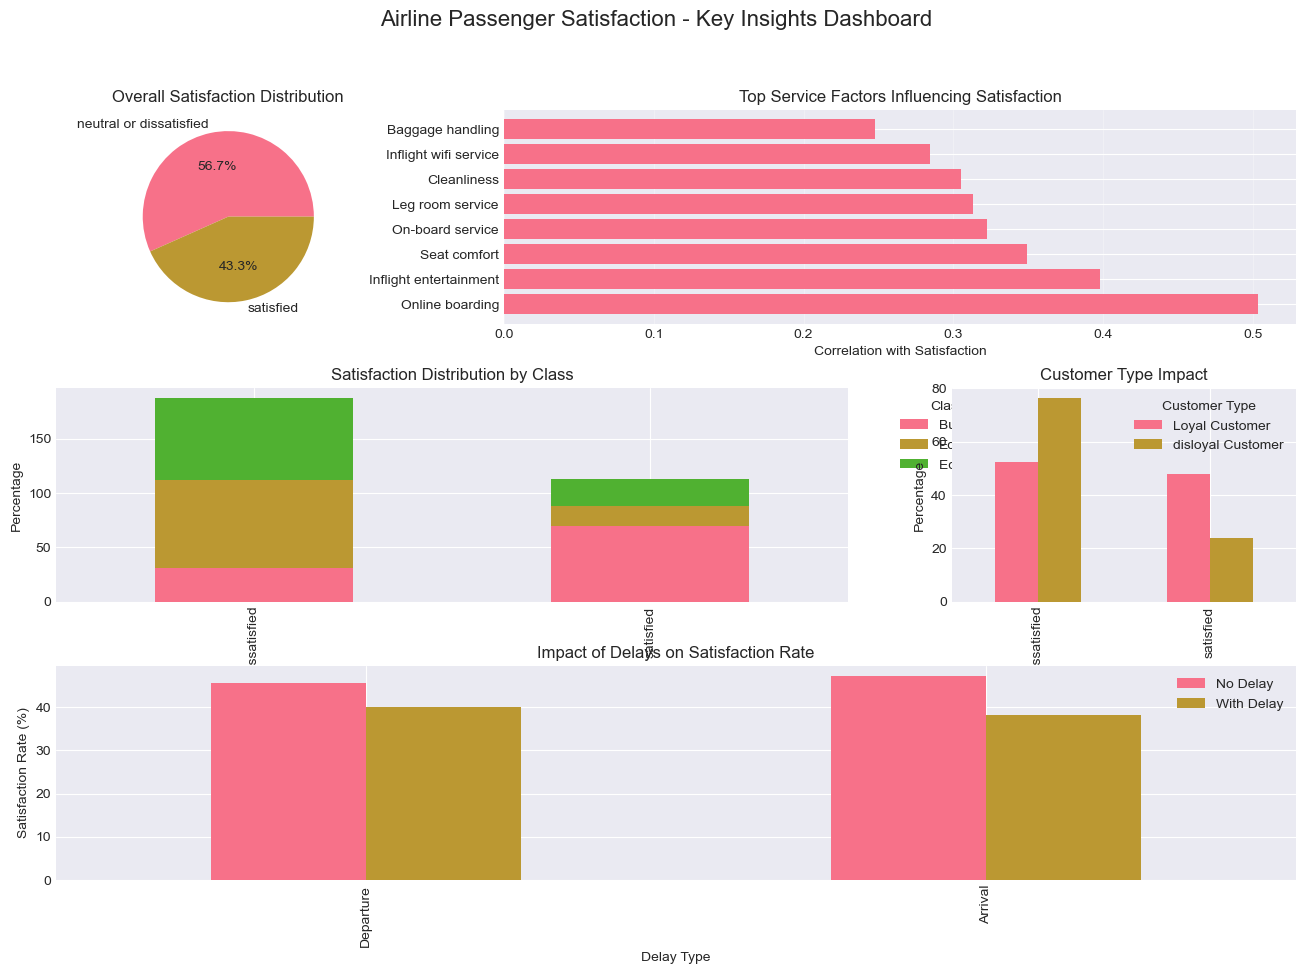

In [24]:
# Create a dashboard-style visualization
fig = plt.figure(figsize=(16, 10))

# Overall metrics
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Satisfaction pie chart
ax1 = fig.add_subplot(gs[0, 0])
satisfaction_counts.plot(kind='pie', ax=ax1, autopct='%1.1f%%')
ax1.set_title('Overall Satisfaction Distribution')
ax1.set_ylabel('')

# Top service factors
if service_columns and 'corr_df' in locals():
    ax2 = fig.add_subplot(gs[0, 1:])
    top_factors = corr_df.head(8)
    ax2.barh(top_factors['Feature'], top_factors['Correlation'])
    ax2.set_xlabel('Correlation with Satisfaction')
    ax2.set_title('Top Service Factors Influencing Satisfaction')
    ax2.grid(axis='x', alpha=0.3)

# Class distribution by satisfaction
ax3 = fig.add_subplot(gs[1, :2])
class_satisfaction.T.plot(kind='bar', ax=ax3, stacked=True)
ax3.set_title('Satisfaction Distribution by Class')
ax3.set_ylabel('Percentage')
ax3.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Customer type analysis
ax4 = fig.add_subplot(gs[1, 2])
customer_satisfaction.T.plot(kind='bar', ax=ax4)
ax4.set_title('Customer Type Impact')
ax4.set_ylabel('Percentage')
ax4.legend(title='Customer Type')

# Delay impact
ax5 = fig.add_subplot(gs[2, :])
delay_impact = pd.DataFrame({
    'No Delay': [
        len(df[(df['Departure Delay in Minutes'] == 0) & (df['satisfaction'] == 'satisfied')]) / 
        len(df[df['Departure Delay in Minutes'] == 0]) * 100,
        len(df[(df['Arrival Delay in Minutes'] == 0) & (df['satisfaction'] == 'satisfied')]) / 
        len(df[df['Arrival Delay in Minutes'] == 0]) * 100
    ],
    'With Delay': [
        len(df[(df['Departure Delay in Minutes'] > 0) & (df['satisfaction'] == 'satisfied')]) / 
        len(df[df['Departure Delay in Minutes'] > 0]) * 100,
        len(df[(df['Arrival Delay in Minutes'] > 0) & (df['satisfaction'] == 'satisfied')]) / 
        len(df[df['Arrival Delay in Minutes'] > 0]) * 100
    ]
}, index=['Departure', 'Arrival'])

delay_impact.plot(kind='bar', ax=ax5)
ax5.set_title('Impact of Delays on Satisfaction Rate')
ax5.set_ylabel('Satisfaction Rate (%)')
ax5.set_xlabel('Delay Type')
ax5.legend()

plt.suptitle('Airline Passenger Satisfaction - Key Insights Dashboard', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Conclusions and Recommendations

In [25]:
print("\n" + "="*60)
print("CONCLUSIONS AND RECOMMENDATIONS")
print("="*60)

print("\n1. SERVICE QUALITY IMPROVEMENTS:")
if service_columns and 'service_gaps' in locals():
    bottom_services = service_gaps.tail(3)
    print("   Priority areas for improvement (lowest satisfaction gaps):")
    for service in bottom_services.index:
        print(f"   - {service}: Gap of {bottom_services[service]:.2f} points")

print("\n2. CUSTOMER SEGMENTATION STRATEGY:")
print("   - Focus on converting personal travelers to satisfied customers")
print("   - Maintain high service standards for business class passengers")
print("   - Develop loyalty programs to increase customer retention")

print("\n3. OPERATIONAL EXCELLENCE:")
print("   - Minimize flight delays as they significantly impact satisfaction")
print("   - Improve economy class experience to boost overall satisfaction")

print("\n4. DATA-DRIVEN DECISIONS:")
print("   - Regular monitoring of service ratings across all touchpoints")
print("   - Implement predictive models to identify at-risk customers")
print("   - Continuous feedback collection and analysis")

# Save key metrics to a summary file
summary_dict = {
    'Total_Passengers': total_passengers,
    'Overall_Satisfaction_Rate': satisfaction_rate,
    'Business_Travelers_Satisfaction': business_satisfaction.get('satisfied', 0) * 100 if 'business_satisfaction' in locals() else None,
    'Loyal_Customers_Satisfaction': loyal_satisfaction.get('satisfied', 0) * 100 if 'loyal_satisfaction' in locals() else None
}

print("\n" + "="*60)
print("EDA COMPLETE - Key metrics have been analyzed and visualized")
print("="*60)


CONCLUSIONS AND RECOMMENDATIONS

1. SERVICE QUALITY IMPROVEMENTS:
   Priority areas for improvement (lowest satisfaction gaps):
   - Ease of Online booking: Gap of 0.48 points
   - Gate location: Gap of 0.00 points
   - Departure/Arrival time convenient: Gap of -0.16 points

2. CUSTOMER SEGMENTATION STRATEGY:
   - Focus on converting personal travelers to satisfied customers
   - Maintain high service standards for business class passengers
   - Develop loyalty programs to increase customer retention

3. OPERATIONAL EXCELLENCE:
   - Minimize flight delays as they significantly impact satisfaction
   - Improve economy class experience to boost overall satisfaction

4. DATA-DRIVEN DECISIONS:
   - Regular monitoring of service ratings across all touchpoints
   - Implement predictive models to identify at-risk customers
   - Continuous feedback collection and analysis

EDA COMPLETE - Key metrics have been analyzed and visualized
